#### для работы в google colab

In [3]:
!gdown 1bHtAfjpphYjjG45Y0iOsy7kQr4eplA2H

Downloading...
From: https://drive.google.com/uc?id=1bHtAfjpphYjjG45Y0iOsy7kQr4eplA2H
To: /kaggle/working/Regression_dataset.zip
100%|██████████████████████████████████████| 13.8M/13.8M [00:00<00:00, 39.4MB/s]


In [5]:
import zipfile

zip_path = '/kaggle/working/Regression_dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/kaggle/working/regression_dataset')

print("📁 Архив распакован.")


📁 Архив распакован.


In [6]:
import pandas as pd

In [29]:
# для google colab

images_folder = '/kaggle/working/regression_dataset/train/'
test_folder = '/kaggle/working/regression_dataset/test/'

df = pd.read_csv('/kaggle/working/regression_dataset/train.csv')
test = pd.read_csv('/kaggle/working/regression_dataset/test.csv')

df.head()

,likes,reposts,views,filename,url
0,3854.0,6578.0,1051097.0,935.jpg,https://sun9-46.userapi.com/s/v1/if2/TO7aTYbdN...
1,374.0,476.0,86354.0,290.jpg,https://sun9-85.userapi.com/s/v1/ig2/RGUtvk0yD...
2,135.0,67.0,54483.0,544.jpg,https://sun9-36.userapi.com/s/v1/ig2/9H6EEHaUA...
3,240.0,1228.0,191603.0,275.jpg,https://sun9-57.userapi.com/s/v1/ig2/_3Xhtrcnf...
4,225.0,220.0,105902.0,109.jpg,https://sun9-42.userapi.com/s/v1/ig2/mmvCLMYDp...


### Выгружаем данные и убираем лишние классы

In [30]:
import pandas as pd
import numpy as np

In [31]:
# # для локального запуска
# import os

# if os.getcwd().split('/')[-1] != 'memobot':
#     os.chdir('..')
# os.getcwd()


In [44]:
# images_folder = 'data/regression_dataset/train/'
# test_folder = 'data/regression_dataset/test/'

# df = pd.read_csv('data/regression/train.csv')
# test = pd.read_csv('data/regression/test.csv')

# df.head()

## Собираем датасет

In [45]:
from torch.utils.data import Dataset, DataLoader
import torch
from PIL import Image

class VkDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image = Image.open(img_path).convert('RGB')
        targets = torch.Tensor([row['likes'], row['reposts'], row['views']])

        if self.transform:
            image = self.transform(image)

        return image, targets


In [46]:
from torch.utils.data import random_split
from torchvision import transforms

torch.manual_seed(42)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_data = VkDataset(df, images_folder, transform=transform)
test_data = VkDataset(test, test_folder, transform=transform)

train_ds, val_ds = random_split(train_data, [0.8, 0.2])

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=32, shuffle=False)

test_dl = DataLoader(test_data, batch_size=32, shuffle=False)


In [47]:
len(train_data), len(test_data)

(759, 190)

### Быстрые функции обучения и тестирования модели

In [71]:
import torch.nn as nn
from tqdm import tqdm


def train_model(model, model_path, n_epochs=5, batch_size=32, optimizer=None, criterion=None):
    if not optimizer:
        optimizer = torch.optim.Adam(model.parameters())
    if not criterion:
        criterion = nn.MSELoss()

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_dl = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    
    best_loss = float('inf')
    
    
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
    
        for image, targets in tqdm(train_dl, desc=f"Epoch {epoch+1} [Train]", leave=False):
            image, targets = image.to(device), targets.to(device)
            preds = model(image)
            loss = criterion(preds, targets)
    
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
            total_loss += loss.item()
    
        model.eval()
        val_loss = 0
    
        for image, targets in tqdm(val_dl, desc=f"Epoch {epoch+1} [Val]", leave=False):
            image, targets = image.to(device), targets.to(device)
            with torch.no_grad():
                preds = model(image)
                loss = criterion(preds, targets)
            
            val_loss += loss.item()
    
        val_loss /= len(val_dl)
        total_loss /= len(train_dl)
    
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), model_path)
    
        print(f"Epoch {epoch+1} [Train] Loss: {total_loss:.4f}, [Val] Loss: {val_loss:.4f}")

In [72]:
def test_model(model, criterion):
    test_loss = 0
    
    for image, targets in tqdm(test_dl, desc=f"Epoch {epoch+1} [Test]"):
        image, targets = image.to(device), targets.to(device)
        with torch.no_grad():
            preds = model(image)
            loss = criterion(preds, targets)
        test_loss += loss.item()
    
    test_loss /= len(test_dl)
    
    print(f"Test Loss: {test_loss:.4f}")

# Сначала EfficientNet

In [73]:
from torchvision import models

model = models.efficientnet_b0()
model.classifier[1] = nn.Linear(1280, 3)
model.to(device)

In [74]:
train_model(model, '/kaggle/working/efficientnet_regressor.pth', n_epochs=10)

Epoch 1 [Train] Loss: 69885556574.3158, [Val] Loss: 60325821235.2000


Epoch 2 [Train] Loss: 69884402095.1579, [Val] Loss: 60325110988.8000


Epoch 3 [Train] Loss: 69882463178.1053, [Val] Loss: 60319985254.4000


Epoch 4 [Train] Loss: 69878344596.2105, [Val] Loss: 60326138265.6000


Epoch 5 [Train] Loss: 69875223605.8947, [Val] Loss: 60313714688.0000


Epoch 6 [Train] Loss: 69871914145.6842, [Val] Loss: 60306296832.0000


Epoch 7 [Train] Loss: 69866576626.5263, [Val] Loss: 60323828121.6000


Epoch 8 [Train] Loss: 69858750895.1579, [Val] Loss: 60308509491.2000


Epoch 9 [Train] Loss: 69856015575.5789, [Val] Loss: 60321969766.4000


Epoch 10 [Train] Loss: 69849610024.4211, [Val] Loss: 60309965619.2000


In [75]:
model = models.efficientnet_b0()
model.classifier[1] = nn.Linear(1280, 3)

model.load_state_dict(torch.load('/kaggle/working/efficientnet_regressor.pth'))

model.eval()
model.to(device)

test_model(model, criterion)

Epoch 10 [Test]: 100%|██████████| 6/6 [00:00<00:00,  9.42it/s]

Test Loss: 62916234410.6667


### теперь посмотрим сами

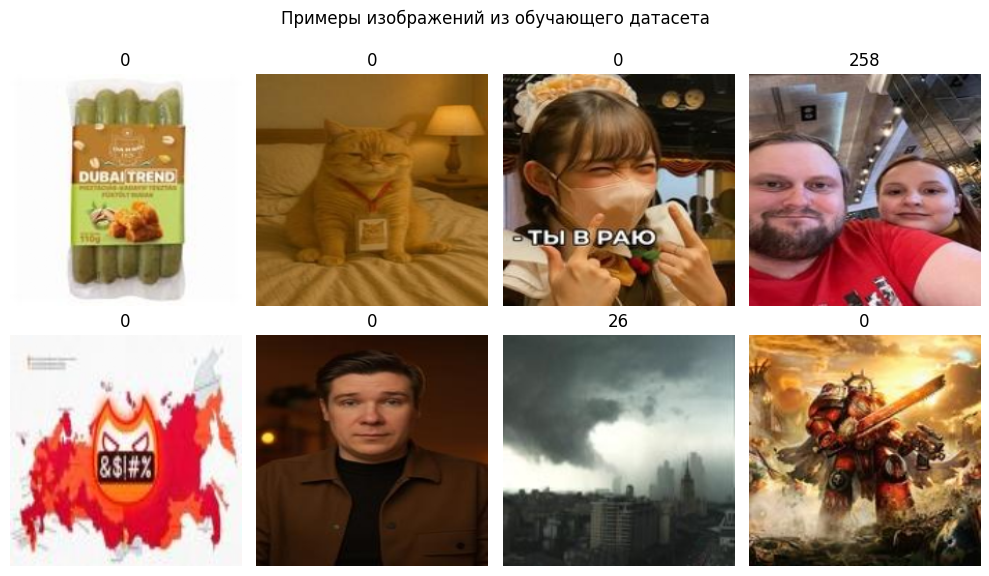

In [78]:
import matplotlib.pyplot as plt

plt.subplots(2, 4, figsize=(10, 6))
plt.suptitle("Примеры изображений из обучающего датасета")
j = 1
for i in np.random.randint(0, len(test_data), 8):
    plt.subplot(2, 4, j)
    j += 1

    img = test_data[i][0].to(device).unsqueeze(0)
    
    with torch.no_grad():
      targets = model(img).relu().int()
    plt.imshow(test_data[i][0].permute(1, 2, 0).numpy())  # Преобразуем тензор в формат [H, W, C]
    plt.title(f"{targets[0][0].cpu().numpy()}")
    plt.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# Теперь ResNet

In [79]:
from torchvision import models
import torch.nn as nn

model = models.resnet50()
model.fc = nn.Linear(2048, 3)
model.to(device)

In [80]:
train_model(model, '/kaggle/working/resnet_regressor.pth', n_epochs=10)

Epoch 1 [Train] Loss: 69879084301.4737, [Val] Loss: 60270452326.4000


Epoch 2 [Train] Loss: 69865876695.5789, [Val] Loss: 60293530828.8000


Epoch 3 [Train] Loss: 69848663471.1579, [Val] Loss: 60274617139.2000


Epoch 4 [Train] Loss: 69830367555.3684, [Val] Loss: 60264017100.8000


Epoch 5 [Train] Loss: 69808271521.6842, [Val] Loss: 60236820070.4000


Epoch 6 [Train] Loss: 69781752778.1053, [Val] Loss: 60209035264.0000


Epoch 7 [Train] Loss: 69757854504.4211, [Val] Loss: 60212473856.0000


Epoch 8 [Train] Loss: 69731892709.0526, [Val] Loss: 60160646758.4000


Epoch 9 [Train] Loss: 69699639511.5789, [Val] Loss: 60136599961.6000


Epoch 10 [Train] Loss: 69671075732.2105, [Val] Loss: 60097854259.2000


In [81]:
model = models.resnet50()
model.fc = nn.Linear(2048, 3)

model.load_state_dict(torch.load('/kaggle/working/resnet_regressor.pth'))

model.eval()
model.to(device)

test_model(model, criterion)

Epoch 10 [Test]: 100%|██████████| 6/6 [00:00<00:00,  6.43it/s]

Test Loss: 62710205952.0000


In [ ]:
import matplotlib.pyplot as plt

plt.subplots(2, 4, figsize=(10, 6))
plt.suptitle("Примеры изображений из обучающего датасета")
j = 1
for i in np.random.randint(0, len(test_data), 8):
    plt.subplot(2, 4, j)
    j += 1

    img = test_data[i][0].to(device).unsqueeze(0)
    
    with torch.no_grad():
      targets = model(img)
    plt.imshow(test_data[i][0].permute(1, 2, 0).numpy())
    plt.title(f"{targets[0][0].item()} likes, {targets[1][0]} reposts")
    plt.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()